# Where should the shots go?

Four short circuits, a perfect device, and one question: **is the X gate over-rotating, and is
it tilted?**

Those are two numbers to estimate, so each circuit's usefulness is a single arrow in a plane --
which makes the whole problem something you can draw and check by hand.

Two ways to spend a fixed shot budget:

- **LM** splits it evenly. Every circuit gets the same number of shots
  (`lm_arms.py`: `per = target_shots / len(circuits)`).
- **adaptive-D** maximises `log det H` over the shot fractions and splits the budget by what
  each circuit actually measures.

### No noise anywhere

The device here is **ideal** -- the gates are perfect. That is not a simplification for the
demo's sake, it is how experiment design actually works: you choose where to spend shots
*before* you know the errors, so the design is computed from the target gate set. What the
gradients measure is not "how much error is there" but "how much would this circuit's outcome
move *if* there were an error".

### The mechanism, in one box

Each circuit contributes Fisher information

    A_s = (grad p_s)(grad p_s)' / (p_s (1 - p_s))
    H(n) = sum_s n_s A_s          (n_s = shots on circuit s)

and the design maximises `det H`. A determinant is zero if **any** direction goes unmeasured,
which is what stops the budget from piling onto whichever circuit responds most strongly.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pygsti

SSE = Path.cwd()                                   # run from seed_sweep_experiments
sys.path.insert(0, str(SSE))
sys.path.insert(0, str(SSE.parent))                # GST_POUNDERS, for adaptive_shots

from gst_seed_experiment import ExperimentConfig, GSTProblem, _make_parameterized_model
import adaptive_shots as ashots

N_SHOTS = 100_000
BASELINE_FRAC = 0.001     # token uniform floor, as the production method uses

cfg = ExperimentConfig.from_json(SSE / "experiment_config.json")
prob = GSTProblem(cfg, 101)
mp = prob.modelpack
prep_fids, meas_fids = mp.prep_fiducials(), mp.meas_fiducials()

# The IDEAL gate set -- no noise. Sensitivities are evaluated at the perfect device.
ideal = _make_parameterized_model(prob.raw_target_model, cfg.parameterization,
                                  ideal_model=prob.raw_target_model)

# The two things we want to learn about the X gate.
labels = [str(l) for l in ideal.parameter_labels]
TARGET = ([i for i, l in enumerate(labels)
           if "Gxpi2" in l and l.endswith("'X Hamiltonian error coefficient')")]
          + [i for i, l in enumerate(labels)
             if "Gxpi2" in l and l.endswith("'Z Hamiltonian error coefficient')")])

print(f"{cfg.modelpack_1q}, ideal gate set, {len(labels)} model parameters in total")
print("we ask about just two of them:")
print("   dX  -- X Hamiltonian coefficient of the Gxpi2 error generator  (over-rotation)")
print("   dZ  -- Z Hamiltonian coefficient of the Gxpi2 error generator  (tilt)")

smq1Q_XYZI, ideal gate set, 72 model parameters in total
we ask about just two of them:
   dX  -- X Hamiltonian coefficient of the Gxpi2 error generator  (over-rotation)
   dZ  -- Z Hamiltonian coefficient of the Gxpi2 error generator  (tilt)


## The four circuits

Short enough to read off the page. `Gx` is `Gxpi2`, a 90-degree rotation about X; `Gy` is
`Gypi2`.

| | body | why it is here |
|---|---|---|
| **A** | `Gx` | one gate, read out one way |
| **B** | `Gx` | **the same single gate**, read out on another axis |
| **C** | `Gy Gx Gx` | three gates, the strongest responder of the four |
| **D** | `idle` | prepared and measured on the same axis -- **blind** |

A and B are the interesting pair: the *same physical gate*, differing only in how the result is
read out. Any difference between them is about visibility, not about the gates.

D is the one whose answer is known in advance. It is prepared along Z, left alone, and measured
along Z. It never leaves the axis it starts on, so an error rotating it about that axis changes
nothing that can be seen. Any sensible allocator must refuse to spend on it.

In [2]:
Gx = pygsti.circuits.Circuit([('Gxpi2', 0)])
Gy = pygsti.circuits.Circuit([('Gypi2', 0)])

FOUR = [("A   Gx         (readout 1)", prep_fids[0] + Gx           + meas_fids[3]),
        ("B   Gx         (readout 2)", prep_fids[0] + Gx           + meas_fids[2]),
        ("C   Gy Gx Gx",               prep_fids[1] + Gy + Gx + Gx + meas_fids[3]),
        ("D   idle       (blind)",     prep_fids[0] +                meas_fids[0])]
LABELS = [lab for lab, _ in FOUR]
CIRCS = [c for _, c in FOUR]

for lab, c in FOUR:
    print(f"{lab}")
    print(f"      full circuit (fiducials included):  {c.str}")

A   Gx         (readout 1)
      full circuit (fiducials included):  Gxpi2:0Gxpi2:0Gxpi2:0@(0)
B   Gx         (readout 2)
      full circuit (fiducials included):  Gxpi2:0Gypi2:0@(0)
C   Gy Gx Gx
      full circuit (fiducials included):  Gxpi2:0Gypi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0@(0)
D   idle       (blind)
      full circuit (fiducials included):  {}@(0)


### What each circuit can see

`grad p = (dp/ddX, dp/ddZ)` says how the outcome probability would move if the gate were
over-rotating (`dX`) or tilted (`dZ`). It is the circuit's sensitivity, and on an ideal device
it comes out exact.

In [3]:
pr = ideal.bulk_probabilities(CIRCS)
dp = ideal.sim.bulk_dprobs(CIRCS)

grad, prob_out = [], []
for c in CIRCS:
    outcome = list(ideal.probabilities(c).keys())[0]
    prob_out.append(float(pr[c].get(outcome, 0.0)))
    grad.append(np.asarray(dp[c][outcome], dtype=float)[TARGET])
grad, prob_out = np.array(grad), np.array(prob_out)


def angle_of(g):
    """Direction of a gradient in the (dX, dZ) plane, as an axis in [0, 180)."""
    return np.degrees(np.arctan2(g[1], g[0])) % 180.0


print(f"{'circuit':<30}{'p':>7}{'grad = (d/ddX, d/ddZ)':>24}{'|grad|':>9}{'axis':>8}")
for i, lab in enumerate(LABELS):
    n = np.linalg.norm(grad[i])
    axis = "  --  " if n < 1e-12 else f"{angle_of(grad[i]):5.1f}d"
    print(f"{lab:<30}{prob_out[i]:>7.2f}"
          f"{f'({grad[i][0]:+.2f}, {grad[i][1]:+.2f})':>24}{n:>9.3f}{axis:>8}")
print()
print("Exact values on a perfect device: |grad| is 3, 1 and sqrt(17) = 4.123, and every")
print("informative circuit sits at p = 0.5, so none of them is handicapped by shot noise.")
print("D's gradient is exactly zero -- not small, zero. Its probability is pinned at 1.")

circuit                             p   grad = (d/ddX, d/ddZ)   |grad|    axis
A   Gx         (readout 1)       0.50          (+3.00, +0.00)    3.000    0.0d
B   Gx         (readout 2)       0.50          (+0.00, -1.00)    1.000   90.0d
C   Gy Gx Gx                     0.50          (-4.00, -1.00)    4.123   14.0d
D   idle       (blind)           1.00          (+0.00, +0.00)    0.000    --  

Exact values on a perfect device: |grad| is 3, 1 and sqrt(17) = 4.123, and every
informative circuit sits at p = 0.5, so none of them is handicapped by shot noise.
D's gradient is exactly zero -- not small, zero. Its probability is pinned at 1.


### Who overlaps whom

Strength is not what the criterion rewards. What matters is whether a circuit's gradient points
along an **axis** no other circuit covers. Sign is irrelevant -- information depends on the axis,
not on which way the arrow points -- so `+1.0` and `-1.0` cosines both mean "same axis".

In [4]:
print("cosine between gradients (magnitude; 1.000 = same axis, 0.000 = independent)")
print(f"{'':30}" + "".join(f"{l.split()[0]:>9}" for l in LABELS))
for i, a in enumerate(LABELS):
    row = ""
    for j in range(len(LABELS)):
        na, nb = np.linalg.norm(grad[i]), np.linalg.norm(grad[j])
        row += f"{abs(float(grad[i] @ grad[j] / (na * nb))):>9.3f}" if na * nb > 1e-12 \
               else f"{'--':>9}"
    print(f"{a:<30}{row}")
print()
print("A and C lie almost on the SAME axis (0.970) -- they largely duplicate each other.")
print("A and B are exactly perpendicular (0.000) -- B is the only circuit that sees the tilt.")

cosine between gradients (magnitude; 1.000 = same axis, 0.000 = independent)
                                      A        B        C        D
A   Gx         (readout 1)        1.000    0.000    0.970       --
B   Gx         (readout 2)        0.000    1.000    0.243       --
C   Gy Gx Gx                      0.970    0.243    1.000       --
D   idle       (blind)               --       --       --       --

A and C lie almost on the SAME axis (0.970) -- they largely duplicate each other.
A and B are exactly perpendicular (0.000) -- B is the only circuit that sees the tilt.


## The two allocations

`allocate_shots_per_circuit` is the same function the production runs call. LM's rule is the one
line from `lm_arms.py`.

In [5]:
J = grad
p_rows = prob_out
row_circuit = np.arange(len(FOUR))

base = np.full(len(FOUR), BASELINE_FRAC * N_SHOTS / len(FOUR))
extra, _ = ashots.allocate_shots_per_circuit(
    J, p_rows, int((1 - BASELINE_FRAC) * N_SHOTS), row_circuit,
    n_circuit=base, criterion="D", max_iter=4000)
d_share = 100.0 * (base + extra) / N_SHOTS
lm_share = np.full(len(FOUR), 100.0 / len(FOUR))     # per = target_shots / len(circuits)

print(f"{'circuit':<30}{'|grad|':>9}{'axis':>8}{'LM':>9}{'adaptive-D':>13}")
for i, lab in enumerate(LABELS):
    n = np.linalg.norm(grad[i])
    axis = "  --  " if n < 1e-12 else f"{angle_of(grad[i]):5.1f}d"
    print(f"{lab:<30}{n:>9.3f}{axis:>8}{lm_share[i]:>8.1f}%{d_share[i]:>12.1f}%")
print()
print(f"LM spends {lm_share[3]:.0f}% of the budget on a circuit that measures nothing.")
print(f"adaptive-D gives D nothing, and splits the rest {d_share[0]:.0f} / "
      f"{d_share[1]:.0f} / {d_share[2]:.0f}.")

circuit                          |grad|    axis       LM   adaptive-D
A   Gx         (readout 1)        3.000    0.0d    25.0%        10.0%
B   Gx         (readout 2)        1.000   90.0d    25.0%        45.0%
C   Gy Gx Gx                      4.123   14.0d    25.0%        45.0%
D   idle       (blind)            0.000    --      25.0%         0.0%

LM spends 25% of the budget on a circuit that measures nothing.
adaptive-D gives D nothing, and splits the rest 10 / 45 / 45.


### Reading the result

**The budget is split per direction, not per circuit.** There are two things to learn, so the
two axes get half the budget each. What happens inside each axis is where it gets interesting.

**A is squeezed to 10% even though it is the second-strongest circuit.** A and C sit on almost
the same axis (cosine 0.970), so between them they cover *one* direction and have to share its
half of the budget. C does that job better, so it takes most of the share and A is left with
the remainder.

**B gets 45% while being the weakest informative circuit.** Its gradient is 1.0 against C's
4.123 -- four times smaller -- but it is exactly perpendicular to A and C, so it is the only
circuit in the set that can see whether the gate is tilted. Starve B and that direction goes
unmeasured, which sends `det H` to zero no matter how many shots the other circuits get.

**So B, the weakest, gets 4.5x the shots of A, the second-strongest.** That is the rule:

> **Shots follow uniqueness, not strength.** A circuit is funded for the directions only it can
> see, not for how strongly it responds.

**D gets nothing** -- the one part that was obvious in advance.

Note what this also says about the *equal* case. If three circuits covered three different
axes, one each, they would get exactly a third apiece regardless of their strengths, because
each would own one direction outright. Equal shares are not the allocator idling; they are what
one-circuit-per-direction looks like.

## The figure

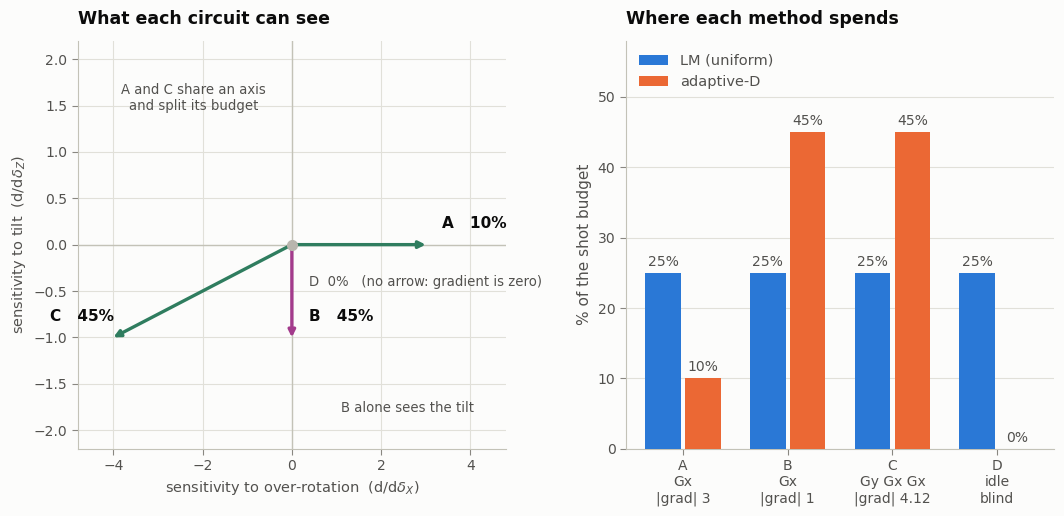

written: C:\Users\athar\Documents\Codex\ANL_SummerInternship\can-you-write-a-code-for\IBCDFO\GST_POUNDERS\seed_sweep_experiments\allocator_demo.png


In [6]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#b8b5ad"
SHARED, SOLO = "#2f7d5f", "#a33b8c"   # left panel is coloured by AXIS, not by method

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.3), facecolor=SURFACE)
fig.subplots_adjust(wspace=0.28)

# ---- left: the gradients as arrows in the (dX, dZ) plane -----------------------------
ax = axes[0]
ax.set_facecolor(SURFACE)
ax.axhline(0, color=AXIS, lw=1, zorder=1)
ax.axvline(0, color=AXIS, lw=1, zorder=1)
cols = {0: SHARED, 1: SOLO, 2: SHARED}
for i in range(3):
    g = grad[i]
    ax.annotate("", xy=(g[0], g[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=cols[i], lw=2.4,
                                shrinkA=0, shrinkB=0), zorder=3)
    lab = LABELS[i].split()[0]
    ax.annotate(f"{lab}   {d_share[i]:.0f}%", (g[0], g[1]),
                textcoords="offset points",
                xytext=(12 if g[0] >= 0 else -46, 12 if g[1] >= 0 else 12),
                color=INK, fontsize=11, fontweight="semibold")
ax.plot(0, 0, "o", ms=7, color=GREY, zorder=4)
ax.annotate("D  0%   (no arrow: gradient is zero)", (0, 0), textcoords="offset points",
            xytext=(12, -30), color=INK2, fontsize=9.5)
lim = 4.8
ax.set_xlim(-lim, lim); ax.set_ylim(-2.2, 2.2)
ax.set_xlabel("sensitivity to over-rotation  (d/d$\\delta_X$)", color=INK2, fontsize=10.5)
ax.set_ylabel("sensitivity to tilt  (d/d$\\delta_Z$)", color=INK2, fontsize=10.5)
ax.set_title("What each circuit can see", color=INK, fontsize=12.5,
             fontweight="semibold", loc="left", pad=12)
ax.tick_params(colors=MUTED, labelcolor=INK2, length=4)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(AXIS)
ax.grid(True, color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.annotate("A and C share an axis\nand split its budget", (-2.2, 1.45),
            color=INK2, fontsize=9.5, ha="center")
ax.annotate("B alone sees the tilt", (2.6, -1.80), color=INK2, fontsize=9.5, ha="center")

# ---- right: the two allocations -------------------------------------------------------
ax = axes[1]
ax.set_facecolor(SURFACE)
ax.grid(True, axis="y", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
x = np.arange(len(FOUR))
ax.bar(x - 0.19, lm_share, width=0.34, color=BLUE, label="LM (uniform)", zorder=3)
ax.bar(x + 0.19, d_share, width=0.34, color=ORANGE, label="adaptive-D", zorder=3)
for xi, (lo, hi) in enumerate(zip(lm_share, d_share)):
    ax.annotate(f"{lo:.0f}%", (xi - 0.19, lo), textcoords="offset points", xytext=(0, 5),
                ha="center", color=INK2, fontsize=10)
    ax.annotate(f"{hi:.0f}%", (xi + 0.19, hi), textcoords="offset points", xytext=(0, 5),
                ha="center", color=INK2, fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f"A\nGx\n|grad| {np.linalg.norm(grad[0]):.0f}",
                    f"B\nGx\n|grad| {np.linalg.norm(grad[1]):.0f}",
                    f"C\nGy Gx Gx\n|grad| {np.linalg.norm(grad[2]):.2f}",
                    "D\nidle\nblind"], fontsize=10)
ax.set_ylabel("% of the shot budget", color=INK2, fontsize=11)
ax.set_ylim(0, 58)
ax.set_title("Where each method spends", color=INK, fontsize=12.5,
             fontweight="semibold", loc="left", pad=12)
ax.tick_params(colors=MUTED, labelcolor=INK2, length=4)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(AXIS)
leg = ax.legend(frameon=False, fontsize=10.5, loc="upper left")
for t in leg.get_texts():
    t.set_color(INK2)

fig.savefig(SSE / "allocator_demo.png", dpi=170, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"written: {SSE / 'allocator_demo.png'}")

## Summary

| circuit | body | `\|grad\|` | axis | LM | adaptive-D |
|---|---|---|---|---|---|
| **A** | `Gx` | 3.000 | 0 deg | 25% | 10% |
| **B** | `Gx` | 1.000 | 90 deg | 25% | **45%** |
| **C** | `Gy Gx Gx` | 4.123 | 14 deg | 25% | 45% |
| **D** | `idle` | 0.000 | -- | 25% | **0%** |

A perfect device, four short circuits, two things to learn. Nothing here depends on a noise
model or on a particular error being present.

Two results worth carrying forward. **Strength does not buy shots**: B is four times weaker
than C and gets nine tenths of what C gets, because it is the only circuit that sees the tilt.
**Similarity loses them**: A is strong but sits on C's axis, so the two of them share one
direction's budget and A ends up with 10%. A circuit is worth funding for what only it can see.

The blind circuit is the easy case, and the one LM gets wrong -- it spends a quarter of the
budget there.